In [ ]:
!pip install torchsummary -q


# 🐾 Pet Insight 360 — Emotion Model Training

Transfer Learning with **MobileNetV2** for Pet Emotion Classification (4 classes)

| Component | Detail |
|---|---|
| Model | MobileNetV2 (ImageNet pretrained) |
| Classes | Angry, Happy, Other, Sad |
| Input Size | 224×224 RGB |
| Output | `pet_emotion.pth` for backend |

In [1]:
!pip install torch torchvision matplotlib seaborn scikit-learn tqdm kagglehub -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Phruk\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


## 📅 Download Dataset & Configuration

In [3]:
import kagglehub

# Download latest version
DATA_DIR = kagglehub.dataset_download("anshtanwar/pets-facial-expression-dataset")
print("Path to dataset files:", DATA_DIR)

# Show contents
for item in sorted(os.listdir(DATA_DIR)):
    full = os.path.join(DATA_DIR, item)
    if os.path.isdir(full):
        count = len([f for f in os.listdir(full) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"  📁 {item}/ — {count} images")

Path to dataset files: C:\Users\Phruk\.cache\kagglehub\datasets\anshtanwar\pets-facial-expression-dataset\versions\11
  📁 Angry/ — 250 images
  📁 Master Folder/ — 0 images
  📁 Other/ — 250 images
  📁 Sad/ — 250 images
  📁 happy/ — 250 images


In [4]:
# ============================================================
# Configuration
# ============================================================
EMOTION_LABELS = ["angry", "happy", "other", "sad"]
NUM_CLASSES = len(EMOTION_LABELS)
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30
LR = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 0 if sys.platform == 'win32' else 2

print(f"Device: {DEVICE}")
print(f"Classes: {EMOTION_LABELS}")
print(f"Batch size: {BATCH_SIZE} | Epochs: {EPOCHS} | Workers: {NUM_WORKERS}")

Device: cuda
Classes: ['angry', 'happy', 'other', 'sad']
Batch size: 32 | Epochs: 30 | Workers: 0


## 📂 Load Dataset

In [5]:
class PetEmotionDataset(Dataset):
    def __init__(self, root_dir, emotion_labels, transform=None):
        self.samples = []
        self.transform = transform
        
        # Case-insensitive folder matching
        all_folders = {f.lower(): f for f in os.listdir(root_dir)
                       if os.path.isdir(os.path.join(root_dir, f))}
        
        for idx, label in enumerate(emotion_labels):
            folder_name = all_folders.get(label.lower())
            if folder_name is None:
                print(f"  ⚠️ [{idx}] '{label}' — NOT FOUND")
                continue
            folder_path = os.path.join(root_dir, folder_name)
            count = 0
            for fname in os.listdir(folder_path):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    self.samples.append((os.path.join(folder_path, fname), idx))
                    count += 1
            print(f"  ✅ [{idx}] {label:>8s} → '{folder_name}/' — {count} images")
        
        print(f"  📊 Total: {len(self.samples)} images")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert("RGB")
        except:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (0, 0, 0))
        if self.transform:
            img = self.transform(img)
        return img, label

print("Loading dataset...")
full_dataset = PetEmotionDataset(DATA_DIR, EMOTION_LABELS)
assert len(full_dataset) > 0, "Dataset is empty! Check DATA_DIR."

Loading dataset...
  ✅ [0]    angry → 'Angry/' — 250 images
  ✅ [1]    happy → 'happy/' — 250 images
  ✅ [2]    other → 'Other/' — 250 images
  ✅ [3]      sad → 'Sad/' — 250 images
  📊 Total: 1000 images


## 🔄 Data Augmentation & DataLoaders

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Split 80/20
n_total = len(full_dataset)
n_val = int(0.2 * n_total)
n_train = n_total - n_val

train_indices, val_indices = random_split(
    range(n_total), [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

class SubsetWithTransform(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = list(indices)
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        path, label = self.dataset.samples[self.indices[idx]]
        try:
            img = Image.open(path).convert("RGB")
        except:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (0, 0, 0))
        if self.transform:
            img = self.transform(img)
        return img, label

train_ds = SubsetWithTransform(full_dataset, train_indices, train_transform)
val_ds = SubsetWithTransform(full_dataset, val_indices, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"\n✅ Train: {len(train_ds)} | Val: {len(val_ds)}")
print(f"✅ Batches: {len(train_loader)} train / {len(val_loader)} val")


✅ Train: 800 | Val: 200
✅ Batches: 25 train / 7 val


## 🔍 Visualize Samples

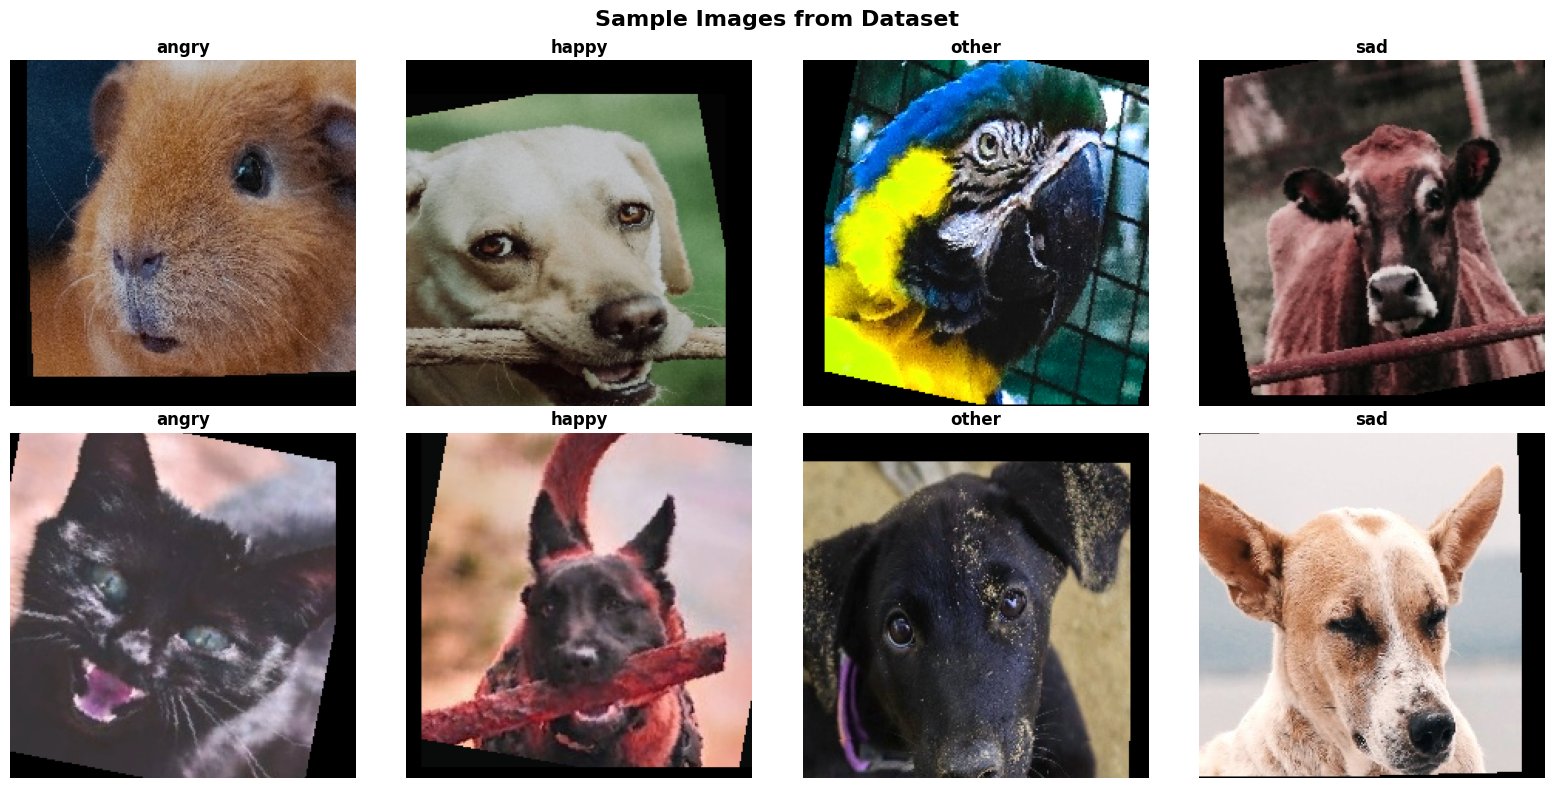

In [7]:
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(4*NUM_CLASSES, 8))
fig.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
shown = {i: 0 for i in range(NUM_CLASSES)}
for img, label in train_ds:
    if shown[label] < 2:
        row, col = shown[label], label
        img_np = np.clip(std * img.permute(1,2,0).numpy() + mean, 0, 1)
        axes[row, col].imshow(img_np)
        axes[row, col].set_title(EMOTION_LABELS[label], fontsize=12, fontweight='bold')
        axes[row, col].axis('off')
        shown[label] += 1
    if all(v >= 2 for v in shown.values()): break
plt.tight_layout()
plt.show()

## 🧠 Model Definition — MobileNetV2 Transfer Learning

In [8]:
class PetEmotionNet(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        in_features = backbone.last_channel
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )
        for i, param in enumerate(self.features.parameters()):
            if i < 100:
                param.requires_grad = False

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

model = PetEmotionNet(num_classes=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"PetEmotionNet | Total: {total_params:,} | Trainable: {trainable:,} | Device: {DEVICE}")

PetEmotionNet | Total: 2,552,836 | Trainable: 2,191,556 | Device: cuda


In [ ]:
from torchsummary import summary
summary(model, input_size=(3, 224, 224))


## 🏋️ Training

In [9]:
# Class weights
class_counts = [0] * NUM_CLASSES
for _, label in full_dataset.samples:
    class_counts[label] += 1
total_samples = sum(class_counts)
class_weights = torch.tensor(
    [total_samples / (NUM_CLASSES * c) if c > 0 else 1.0 for c in class_counts],
    dtype=torch.float32
).to(DEVICE)

print("Class distribution:")
for i, (name, count) in enumerate(zip(EMOTION_LABELS, class_counts)):
    print(f"  {name:>8s}: {count:>5d} images (weight: {class_weights[i]:.2f})")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=5e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5, verbose=True)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
patience_counter = 0
PATIENCE = 10

print(f"\n{'='*70}")
print(f"{'Epoch':>6s} | {'Train Loss':>10s} | {'Train Acc':>10s} | {'Val Loss':>10s} | {'Val Acc':>10s} | Status")
print(f"{'='*70}")

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "pet_emotion.pth")
        status = "Best!"
        patience_counter = 0
    else:
        patience_counter += 1
        status = f"wait ({patience_counter}/{PATIENCE})"

    print(f"{epoch+1:>4d}/{EPOCHS} | {train_loss:>10.4f} | {train_acc:>9.2%} | {val_loss:>10.4f} | {val_acc:>9.2%} | {status}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"{'='*70}")
print(f"Best Validation Accuracy: {best_val_acc:.2%}")

Class distribution:
     angry:   250 images (weight: 1.00)
     happy:   250 images (weight: 1.00)
     other:   250 images (weight: 1.00)
       sad:   250 images (weight: 1.00)

 Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc | Status


   1/30 |     1.2171 |    45.88% |     1.2242 |    56.00% | Best!


   2/30 |     0.8122 |    66.75% |     0.9921 |    65.00% | Best!


   3/30 |     0.5605 |    80.62% |     0.9677 |    64.00% | wait (1/10)


   4/30 |     0.4537 |    84.75% |     0.6021 |    84.00% | Best!


...

  20/30 |     0.0489 |    98.12% |     0.1038 |    94.50% | wait (6/10)


  21/30 |     0.0750 |    97.75% |     0.1403 |    95.00% | wait (7/10)


  22/30 |     0.0323 |    98.75% |     0.1324 |    95.00% | wait (8/10)


  23/30 |     0.0495 |    98.00% |     0.1519 |    95.00% | wait (9/10)


  24/30 |     0.0155 |    99.50% |     0.1580 |    96.00% | wait (10/10)

Early stopping at epoch 24
Best Validation Accuracy: 96.00%


In [ ]:
# FINE-TUNING STAGE
print('=== Starting Fine-tuning Stage ===')
for param in model.parameters():
    param.requires_grad = True

optimizer_ft = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode='min', patience=3, factor=0.5, verbose=True)

FT_EPOCHS = 10
for epoch in range(FT_EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f'FT Epoch {epoch+1}/{FT_EPOCHS}', leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer_ft.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_ft.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    train_loss = running_loss / total
    train_acc = correct / total
    
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    scheduler_ft.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'pet_emotion.pth')
        status = 'Best!'
    else:
        status = ''
        
    print(f'FT {epoch+1:>2d}/{FT_EPOCHS} loss: {train_loss:.4f} acc: {train_acc:.2%} val_loss: {val_loss:.4f} val_acc: {val_acc:.2%} {status}')

print(f'Final Fine-tuned Best Accuracy: {best_val_acc:.2%}')


## 📊 Training Curves (Loss & Accuracy)

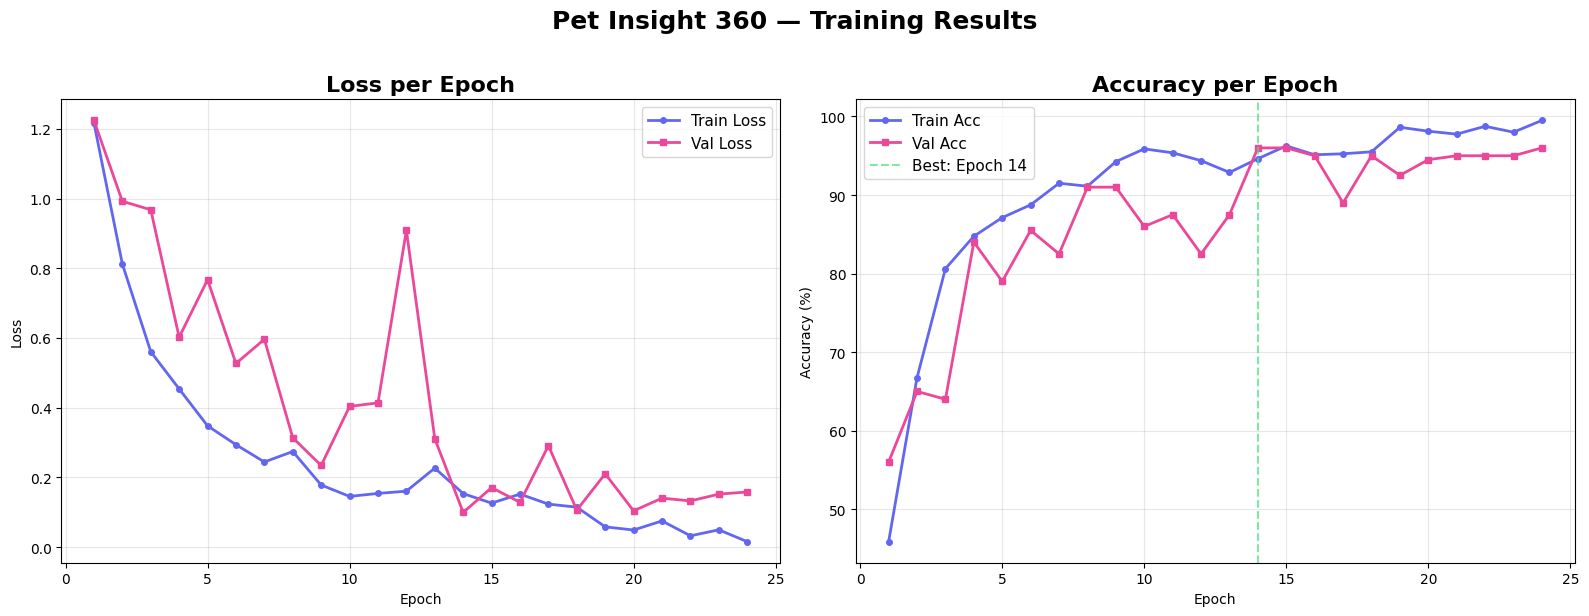

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='#6366f1', linewidth=2, markersize=4)
ax1.plot(epochs_range, history['val_loss'], 's-', label='Val Loss', color='#ec4899', linewidth=2, markersize=4)
ax1.set_title('Loss per Epoch', fontsize=16, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(fontsize=11); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, [a*100 for a in history['train_acc']], 'o-', label='Train Acc', color='#6366f1', linewidth=2, markersize=4)
ax2.plot(epochs_range, [a*100 for a in history['val_acc']], 's-', label='Val Acc', color='#ec4899', linewidth=2, markersize=4)
ax2.set_title('Accuracy per Epoch', fontsize=16, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
best_epoch = np.argmax(history['val_acc'])
ax2.axvline(x=best_epoch+1, color='#4ade80', linestyle='--', alpha=0.7, label=f'Best: Epoch {best_epoch+1}')
ax2.legend(fontsize=11); ax2.grid(True, alpha=0.3)

plt.suptitle('Pet Insight 360 — Training Results', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔍 Confusion Matrix & Classification Report

Evaluating: 100%|██████████| 7/7 [00:00<00:00, 11.93it/s]


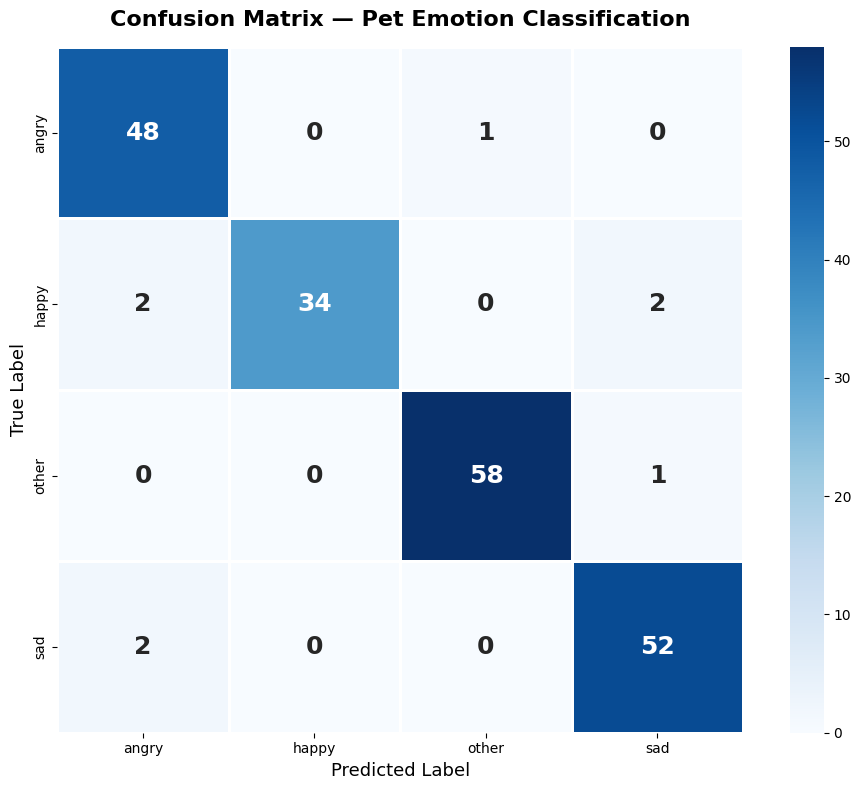


Classification Report:
              precision    recall  f1-score   support

       angry     0.9231    0.9796    0.9505        49
       happy     1.0000    0.8947    0.9444        38
       other     0.9831    0.9831    0.9831        59
         sad     0.9455    0.9630    0.9541        54

    accuracy                         0.9600       200
   macro avg     0.9629    0.9551    0.9580       200
weighted avg     0.9614    0.9600    0.9599       200

Per-Class Accuracy:
     angry: 97.96% (49 samples)
     happy: 89.47% (38 samples)
     other: 98.31% (59 samples)
       sad: 96.30% (54 samples)


In [11]:
model.load_state_dict(torch.load("pet_emotion.pth", map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating"):
        images = images.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
            square=True, linewidths=1, linecolor='white',
            annot_kws={'size': 18, 'fontweight': 'bold'})
plt.title('Confusion Matrix — Pet Emotion Classification', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=EMOTION_LABELS, digits=4))

print("Per-Class Accuracy:")
for i, name in enumerate(EMOTION_LABELS):
    mask = np.array(all_labels) == i
    if mask.sum() > 0:
        acc = (np.array(all_preds)[mask] == i).mean()
        print(f"  {name:>8s}: {acc:.2%} ({mask.sum()} samples)")

## 😻 Test Prediction on Sample Images

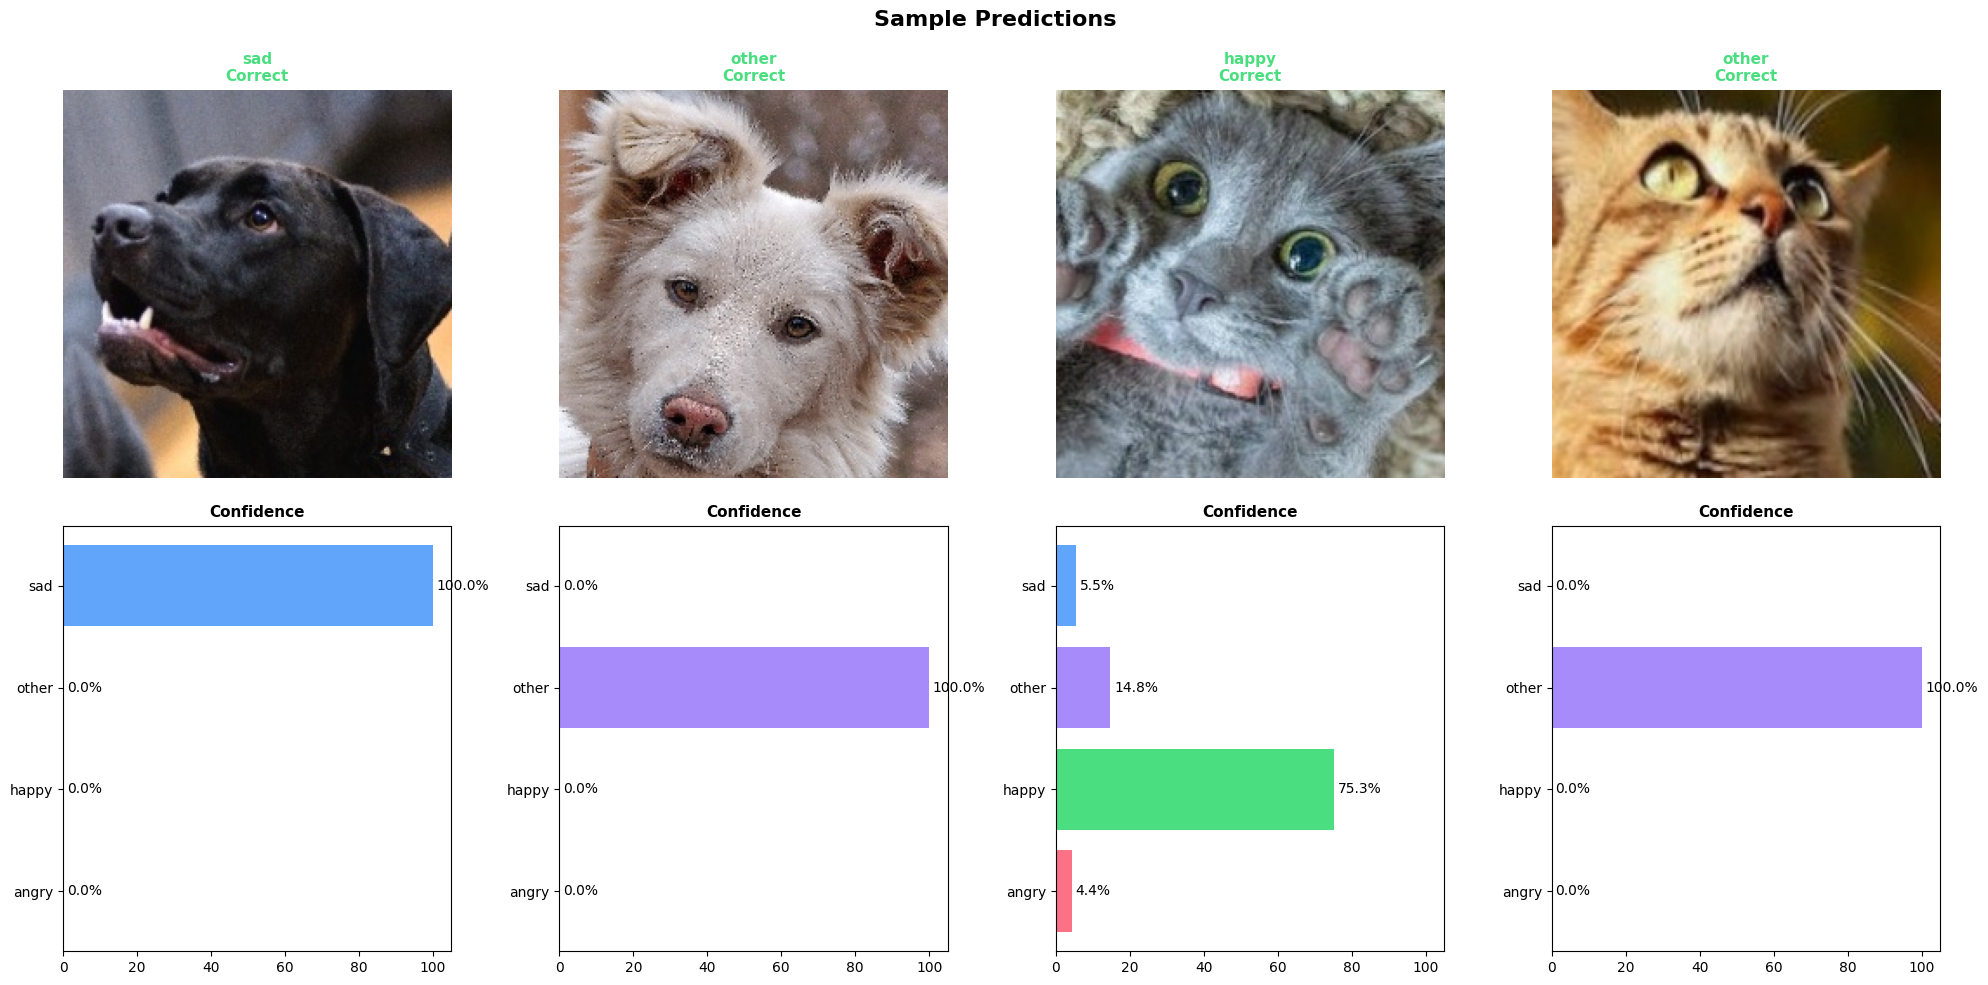

In [12]:
import random
n_samples = min(4, len(val_ds))
sample_indices = random.sample(range(len(val_ds)), n_samples)

fig, axes = plt.subplots(2, n_samples, figsize=(5*n_samples, 10))
if n_samples == 1: axes = axes.reshape(2, 1)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
color_map = {'angry': '#fb7185', 'happy': '#4ade80', 'other': '#a78bfa', 'sad': '#60a5fa'}

for i, sidx in enumerate(sample_indices):
    img_tensor, true_label = val_ds[sidx]
    with torch.no_grad():
        probs = torch.softmax(model(img_tensor.unsqueeze(0).to(DEVICE)), dim=1)[0].cpu().numpy()
        pred_label = np.argmax(probs)
    img_np = np.clip(std * img_tensor.permute(1,2,0).numpy() + mean, 0, 1)
    true_name = EMOTION_LABELS[true_label]
    pred_name = EMOTION_LABELS[pred_label]
    is_correct = true_label == pred_label

    axes[0, i].imshow(img_np)
    axes[0, i].set_title(f"{pred_name}\n{'Correct' if is_correct else 'Wrong (true: '+true_name+')'}",
                         fontsize=11, fontweight='bold', color='#4ade80' if is_correct else '#fb7185')
    axes[0, i].axis('off')

    colors = [color_map.get(e, '#94a3b8') for e in EMOTION_LABELS]
    bars = axes[1, i].barh(EMOTION_LABELS, probs*100, color=colors)
    axes[1, i].set_xlim(0, 105)
    axes[1, i].set_title('Confidence', fontsize=11, fontweight='bold')
    for bar, p in zip(bars, probs):
        axes[1, i].text(bar.get_width()+1, bar.get_y()+bar.get_height()/2, f'{p*100:.1f}%', va='center', fontsize=10)

plt.suptitle('Sample Predictions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 Export Model

Copy `pet_emotion.pth` → `backend/weights/pet_emotion.pth`

In [13]:
size_mb = os.path.getsize('pet_emotion.pth') / (1024*1024)
print(f"File: pet_emotion.pth ({size_mb:.1f} MB)")
print(f"Classes: {EMOTION_LABELS}")
print(f"Best Val Acc: {best_val_acc:.2%}")
print(f"Epochs trained: {len(history['train_loss'])}")
print(f"\nCopy to: backend/weights/pet_emotion.pth")
print("Then run: cd backend && python -m uvicorn app:app --host 0.0.0.0 --port 8000")

File: pet_emotion.pth (10.0 MB)
Classes: ['angry', 'happy', 'other', 'sad']
Best Val Acc: 96.00%
Epochs trained: 24

Copy to: backend/weights/pet_emotion.pth
Then run: cd backend && python -m uvicorn app:app --host 0.0.0.0 --port 8000
